# scBaseCount lung data summary

Analyses the lung-related subset of the scBaseCount human single-cell RNA-seq metadata catalogue (snapshot: 2026-01-12). Loads obs-level and sample-level metadata from Parquet files, applies regex filters, and produces the three figures referenced in `report.md` (§0 — Report summary).

The overall pipeline:
1. **Import** sample & obs metadata from Parquet.
2. **Define regexes** to identify healthy/unknown samples, lung disease/tissue, and cancer.
3. **Filter** samples to build `sample_known`, `lung_union`, `lung_intersection`, and a cancer sub-set.
4. **Visualise** sample breakdown, disease breakdown, and cell-count distribution.

## 1. Data import

In [69]:
from __future__ import annotations

import re
from datetime import datetime, timezone
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.dataset as ds
import matplotlib.pyplot as plt


def _repo_root() -> Path:
    for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (parent / ".git").exists():
            return parent
    raise FileNotFoundError("Could not locate repository root (.git not found).")

_DATA_DIR = _repo_root() / "data/scbasecount/2026-01-12/metadata/GeneFull/Homo_sapiens"

OBS_PARQUET = _DATA_DIR / "scbasecount_2026-01-12_metadata_GeneFull_Homo_sapiens_obs_metadata.parquet"
SAMPLE_PARQUET = _DATA_DIR / "scbasecount_2026-01-12_metadata_GeneFull_Homo_sapiens_sample_metadata.parquet"

# Read data
obs = pq.ParquetFile(OBS_PARQUET)
sample = pd.read_parquet(SAMPLE_PARQUET)

IMAGES_DIR = (Path.cwd() / ".figs").resolve()
IMAGES_DIR.mkdir(exist_ok=True)

sample.columns

Index(['entrez_id', 'srx_accession', 'file_path', 'obs_count', 'lib_prep',
       'tech_10x', 'cell_prep', 'organism', 'tissue',
       'tissue_ontology_term_id', 'disease', 'disease_ontology_term_id',
       'perturbation', 'cell_line', 'antibody_derived_tag',
       'czi_collection_id', 'czi_collection_name'],
      dtype='str')

## 2. Regex

Four case-insensitive regular expressions drive the filtering pipeline. See **report.md §1.2** for a summary table of key terms matched by each.

| Name | Purpose |
|---|---|
| `NORMAL_HEALTHY_REGEX` | Discard healthy / control / unknown samples from both `disease` and `tissue` fields |
| `LUNG_DISEASE_RE` | Keep samples whose `disease` label is lung-related (e.g. `lung`, `pulmonary`, `NSCLC`, `fibrosis`, `COVID-19`) |
| `LUNG_TISSUE_RE` | Keep samples whose `tissue` label is lung-related (e.g. `lung`, `alveol*`, `bronch*`, `pleura`) |
| `CANCER_RE` | Flag samples as cancer vs. non-cancer (e.g. `carcinoma`, `tumour`, `NSCLC`, `mesothelioma`) |

In [70]:
# Regex for normal/healthy/control (from v1, with some adaptation for clarity and consistency)
NORMAL_HEALTHY_REGEX = re.compile(
    (
        r"\b(?:"
        r"normal|healthy|control|none|unknown|unstimulated|naive|"
        r"uninvolved|unaffected|unexposed|vehicle|wild[-_\s]?type|"
        r"wt|no treatment|baseline|"
        r"unsure|not specified|not stated|not reported|not available"
        r")\b"
    ), 
    re.IGNORECASE
)

# Regex to match any lung-related disease (malignant or benign)
# Integration inspired by v1's broad inclusion of lung-related disease and tumor terms
LUNG_DISEASE_RE = re.compile(
    (
        r"\b(?:"
        r"lung|pulmonary|NSCLC|SCLC|adenocarcinoma of the lung|mesothelioma|pleura|"
        r"squamous cell carcinoma of the lung|large[- ]cell|bronch|EGFR|(?<!\w)ALK(?!\w)|ROS1|"
        r"thymoma|thymic|"
        r"cancer|carcinoma|adenocarcinoma|sarcoma|tumou?r|malignancy|"
        r"malignant|benign|neoplasm|mass|adenoma|adenomatous|lesion|"
        r"disease|fibrosis|emphysema|asthma|COPD|bronchitis|pneumonia|"
        r"infection|metastasis|injury"
        r")\b"
        r"|"
        r"\b(?:"
        r"emphysema|asthma|COPD|bronchitis|pneumonia|pulmonary fibrosis|"
        r"interstitial lung disease|"
        r"COVID-19|COVID19|COVID 19|sars-cov-2"
        r")\b"
    ),
    re.IGNORECASE
)

# Regex to match any tissue labels related to lung (from v1)
LUNG_TISSUE_RE = re.compile  (
    (
        r"\b(?:"
        r"lung|pulmonary|alveolus|alveoli|bronchus|bronchi|bronchiole|"
        r"airway|respiratory tract|bronchiolar|thoracic|trachea|pleura|"
        r"interstitium|parenchyma"
        r")\b"
    ),
    re.IGNORECASE
)

CANCER_RE = re.compile(
    (
        r"\b(?:"
        r"cancer|carcinoma|adenocarcinoma|sarcoma|tumou?r|malignancy|malignant|"
        r"neoplasm|neoplastic|leukemia|leukaemia|lymphoma|myeloma|melanoma|"
        r"NSCLC|SCLC|mesothelioma|glioblastoma|glioma|blastoma|"
        r"metastasis|metastatic|oncolog"
        r")\b"
    ),
    re.IGNORECASE
)

## 3. Filter sample df

Builds the analysis subsets from the raw sample metadata. See **report.md §1.1** for the sample counts at each stage and a breakdown table.

| DataFrame | Description | N (approx.) |
|---|---|---|
| `sample_known` | Rows where **neither** `disease` nor `tissue` matches `NORMAL_HEALTHY_REGEX` | 18,550 |
| `lung_union` | `sample_known` where disease **or** tissue is lung-related | 7,986 |
| `lung_intersection` | `sample_known` where disease **and** tissue are both lung-related — **primary analysis set** | 858 |
| `lung_intersection_cancer` | Lung-intersection rows whose `disease` label matches `CANCER_RE` | 361 |
| `not_lung_union` | `sample_known` outside the lung union | 10,564 |
| `not_lung_intersection` | `sample_known` outside the lung intersection | 17,692 |

Partition checks confirm that `lung_union + not_lung_union == sample_known` and similarly for the intersection.

In [71]:
# Start by filtering out any samples with less than 1000 cells
print(f"% SRX with < 1,000 cells: {(sample['obs_count'] < 1000).mean() * 100:.1f}%")
sample = sample[sample["obs_count"] >= 1000]

# Mask for known (not unknown/none/unstated) disease and tissue
unknown_mask = sample[["disease", "tissue"]].apply(lambda col: col.str.contains(NORMAL_HEALTHY_REGEX, na=True)).any(axis=1)
sample_known = sample.loc[unknown_mask == False]

print(unknown_mask.value_counts())

# Filter for any row with a lung-related disease
lung_disease_mask = sample_known["disease"].str.contains(LUNG_DISEASE_RE, regex=True, na=False)

# Filter for any row with a lung-related tissue label
lung_tissue_mask = sample_known["tissue"].str.contains(LUNG_TISSUE_RE, regex=True, na=False)

# Union: samples with lung-related disease OR lung-related tissue
lung_union_mask = lung_disease_mask | lung_tissue_mask
lung_union = sample_known.loc[lung_union_mask].reset_index(drop=True)

# Intersection: samples with BOTH lung-related disease AND lung-related tissue
lung_intersection_mask = lung_disease_mask & lung_tissue_mask
lung_intersection = sample_known.loc[lung_intersection_mask].reset_index(drop=True)

# non-lung rows
not_lung_union = sample_known.loc[lung_union_mask == False].reset_index(drop=True)
not_lung_intersection = sample_known.loc[lung_intersection_mask == False].reset_index(drop=True)

# Cancer subset of lung intersection
lung_intersection_cancer_mask = lung_intersection["disease"].str.contains(CANCER_RE, na=False)
lung_intersection_cancer = lung_intersection.loc[lung_intersection_cancer_mask].reset_index(drop=True)


print(f"sample_known:                  {len(sample_known)}")
print(f"lung union:                    {len(lung_union)}")
print(f"lung intersection:             {len(lung_intersection)}")
print(f"lung intersection (cancer):    {len(lung_intersection_cancer)} ({len(lung_intersection_cancer)/len(lung_intersection):.1%} of intersection)")
print(f"not_lung_union:                {len(not_lung_union)}")
print(f"not_lung_intersection:         {len(not_lung_intersection)}")
print(f"partition check — union:       {len(not_lung_union) + len(lung_union) == len(sample_known)}")
print(f"partition check — intersection:{len(not_lung_intersection) + len(lung_intersection) == len(sample_known)}")

% SRX with < 1,000 cells: 5.5%
False    17531
True     15806
Name: count, dtype: int64
sample_known:                  17531
lung union:                    7484
lung intersection:             801
lung intersection (cancer):    346 (43.2% of intersection)
not_lung_union:                10047
not_lung_intersection:         16730
partition check — union:       True
partition check — intersection:True


## 4. Summary figures
### Dataset at a glance

Pie chart that partitions all 35,266 unique SRX accessions into four slices: *Discarded (unknown/healthy)*, *Lung (cancer)*, *Lung (other)*, and *Non-lung known*. Saved as `sample_breakdown.svg`. This figure and the underlying counts are discussed in **report.md §1.1**.

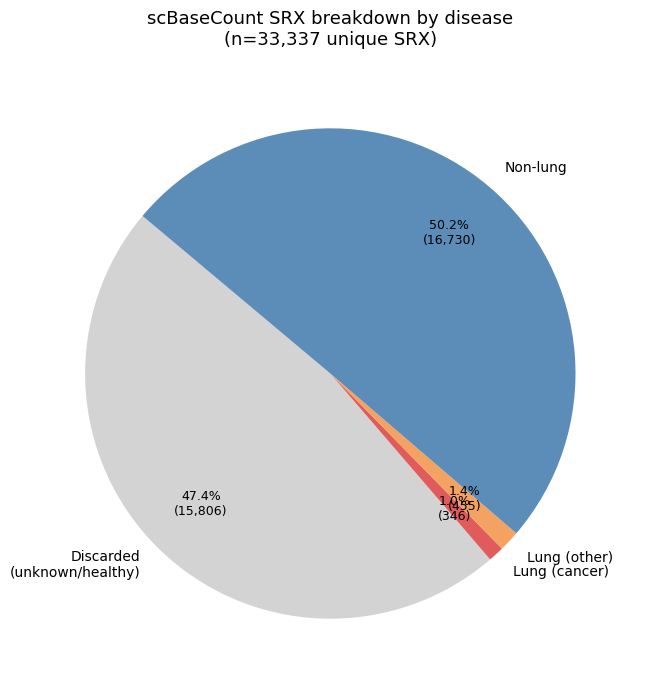

In [72]:
# dataset at a glance
n_total       = len(sample)
n_discarded   = n_total - len(sample_known)
n_lung_cancer = len(lung_intersection_cancer)
n_lung_other  = len(lung_intersection) - n_lung_cancer
n_not_lung    = len(not_lung_intersection)

labels  = [
    "Discarded\n(unknown/healthy)", 
    "Lung (cancer)", 
    "Lung (other)", 
    "Non-lung"
]
sizes   = [n_discarded, n_lung_cancer, n_lung_other, n_not_lung]
colors  = ["#d3d3d3", "#e05c5c", "#f4a261", "#5b8db8"]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * n_total / 100)):,})",
    startangle=140,
    pctdistance=0.75,
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title(f"scBaseCount SRX breakdown by disease\n(n={n_total:,} unique SRX)", fontsize=13, pad=16)
plt.tight_layout()
fig.savefig(IMAGES_DIR / "sample_breakdown.svg", bbox_inches="tight")
plt.show()

### Raw label frequency

Four `value_counts` tables showing the most common free-text labels *as they appear in the dataset*, before any normalisation. These tables appear verbatim in **report.md §2.1**:

- **§2.1.2** — top 10 `tissue` and `disease` labels within the **lung intersection** (858 samples)
- **§2.1.1** — top 10 `disease` and `tissue` labels for the 17,692 **excluded** samples (i.e. `not_lung_intersection`), confirming the filter is working as expected. Note: several COVID-19 entries are excluded here because their `tissue` field is not lung-specific.

In [73]:
# Frequency table of top 20 raw disease and tissue labels
display((lung_intersection["tissue"].value_counts(normalize=True) * 100).head(10))
display((lung_intersection["disease"].value_counts(normalize=True) * 100).head(10))
display((not_lung_intersection["disease"].value_counts(normalize=True) * 100).head(10))
display((not_lung_intersection["tissue"].value_counts(normalize=True) * 100).head(10))

tissue
lung                            52.434457
lung tumor                       3.121099
lung tumour                      1.622971
lung adenocarcinoma              1.373283
lung tissue                      1.248439
lung tumor central margin        1.123596
lung (primary basal cells)       1.123596
lung biopsy                      1.123596
lung tumor subpleural margin     0.998752
parietal pleura                  0.749064
Name: proportion, dtype: float64

disease
lung adenocarcinoma                    13.483146
idiopathic pulmonary fibrosis (IPF)     8.739076
Idiopathic Pulmonary Fibrosis (IPF)     7.865169
SARS-CoV-2 infection                    4.868914
idiopathic pulmonary fibrosis           3.745318
COPD                                    2.871411
non-small cell lung cancer (NSCLC)      2.746567
lung adenocarcinoma (LUAD)              2.746567
pulmonary fibrosis                      2.621723
carcinoma non-small cell                1.997503
Name: proportion, dtype: float64

disease
chronic myelogenous leukemia    4.716079
acute T cell leukemia           2.468619
COVID-19                        2.331142
Chronic Myelogenous Leukemia    1.643754
other                           1.595935
                                1.309026
multiple myeloma                1.075912
breast cancer                   0.950389
glioblastoma                    0.932457
melanoma                        0.884638
Name: proportion, dtype: float64

tissue
CML                                          4.530783
blood                                        4.208010
K562 cell line                               3.448894
bone marrow                                  3.179916
acute T cell leukemia                        2.193664
Peripheral Blood Mononuclear Cells (PBMC)    2.002391
peripheral blood                             1.745368
liver                                        1.464435
skin                                         1.410640
breast                                       1.386730
Name: proportion, dtype: float64

### Lung disease breakdown

Pie chart of the 858 lung-intersection samples broken down by normalised disease category. Free-text labels are mapped to nine curated categories (IPF/Pulmonary Fibrosis, COVID-19, LUAD, NSCLC, etc.) using a second set of regexes defined in the code. Categories that represent < 2 % of the total are collapsed into *Other*. Saved as `lung_disease_breakdown.svg`. This figure is discussed in **report.md §2.2**.

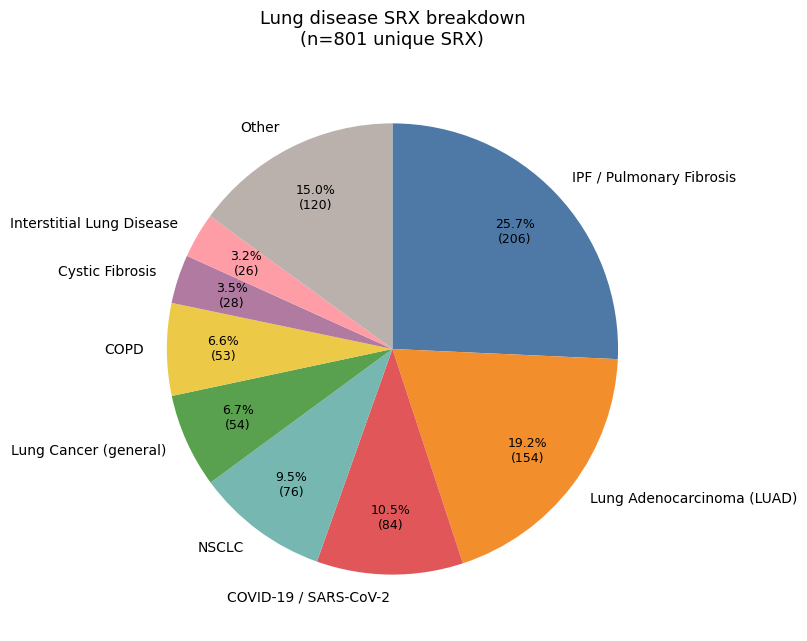

In [74]:
# Lung disease breakdown
disease_map = [
    ("IPF / Pulmonary Fibrosis",     re.compile(r"pulmonary fibrosis|IPF|idiopathic pulmonary fibrosis", re.IGNORECASE)),
    ("COVID-19 / SARS-CoV-2",        re.compile(r"COVID|SARS.CoV", re.IGNORECASE)),
    ("Lung Adenocarcinoma (LUAD)",    re.compile(r"lung adenocarcinoma|LUAD", re.IGNORECASE)),
    ("NSCLC",                         re.compile(r"NSCLC|non.small.cell lung|non.small.cell carcinoma|carcinoma non.small", re.IGNORECASE)),
    ("Lung Squamous Cell Carcinoma",  re.compile(r"squamous cell carcinoma of the lung|lung squamous", re.IGNORECASE)),
    ("COPD",                          re.compile(r"\bCOPD\b", re.IGNORECASE)),
    ("Lung Cancer (general)",         re.compile(r"lung cancer|lung carcinoma|MPLC|KRAS.mutant lung|SCLC", re.IGNORECASE)),
    ("Cystic Fibrosis",               re.compile(r"cystic fibrosis", re.IGNORECASE)),
    ("Interstitial Lung Disease",     re.compile(r"interstitial lung|ILD|SSc", re.IGNORECASE)),
]

def _categorize_disease(d: str) -> str:
    for label, pat in disease_map:
        if pat.search(str(d)):
            return label
    return "Other"

disease_cats = lung_intersection["disease"].map(_categorize_disease)
cat_counts = disease_cats.value_counts()

threshold = 0.02
total_lung = cat_counts.sum()
large = cat_counts[cat_counts / total_lung >= threshold]
small_sum = total_lung - large.sum()
if small_sum > 0:
    large = pd.concat([large, pd.Series({"Other": small_sum})])
# Merge any duplicate index labels (e.g. two "Other" rows)
large = large.groupby(large.index).sum()
# Sort descending; keep "Other" pinned to last
non_other = large.drop("Other", errors="ignore").sort_values(ascending=False)
other_val = large.get("Other", pd.Series(dtype=int))
large = pd.concat([non_other, other_val.rename("Other").to_frame().squeeze() if isinstance(other_val, pd.DataFrame) else (pd.Series({"Other": other_val}) if not isinstance(other_val, pd.Series) else other_val)])

# Tableau 10 palette — high contrast for categorical data; gray reserved for "Other"
tableau10 = [
    "#4e79a7", "#f28e2b", "#e15759", "#76b7b2",
    "#59a14f", "#edc948", "#b07aa1", "#ff9da7",
    "#9c755f",
]
colors = [tableau10[i % len(tableau10)] for i in range(len(large) - 1)] + ["#bab0ac"]

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    large.values,
    labels=large.index,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * total_lung / 100)):,})",
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title(
    f"Lung disease SRX breakdown\n(n={total_lung:,} unique SRX)",
    fontsize=13,
    pad=16,
)
plt.tight_layout()
fig.savefig(IMAGES_DIR / "lung_disease_breakdown.svg", bbox_inches="tight")
plt.show()

### Lung union raw label frequency

The top 10 raw `tissue` labels for the **lung union** (7,986 samples — disease OR tissue is lung-related). This table appears in **report.md §4 Appendix** and reveals how many lung-union samples have non-lung tissue labels (e.g. *blood*, *PBMC*, *liver*), explaining why intersection is used as the primary analysis set rather than the union.

In [75]:
# Frequency table of top 10 raw disease and tissue labels for the lung UNION
display((lung_union["tissue"].value_counts(normalize=True) * 100).head(10))
display((lung_union["disease"].value_counts(normalize=True) * 100).head(10))

tissue
lung                                          6.493854
blood                                         3.621058
breast                                        2.618920
Peripheral Blood Mononuclear Cells (PBMC)     2.324960
liver                                         1.924105
Peripheral blood mononuclear cells (PBMCs)    1.777125
peripheral blood mononuclear cells            1.670230
blood monocyte                                1.469802
brain                                         1.443079
esophageal carcinoma                          1.389631
Name: proportion, dtype: float64

disease
COVID-19                               5.384821
breast cancer                          2.124532
Crohn's disease                        1.857296
lung adenocarcinoma                    1.549973
colorectal cancer                      1.456440
high-grade serous ovarian cancer       1.402993
cardiovascular disease risk factors    1.229289
hepatocellular carcinoma               1.162480
Hepatocellular carcinoma               1.122394
Alzheimer's Disease                    1.082309
Name: proportion, dtype: float64

### Cell count summary & histogram

Quick summary stats and the bottom-30 `obs_count` values for the 858 lung-intersection SRX accessions. The histogram in the next cell visualises the full distribution. Both are discussed in **report.md §3**.

In [76]:
# summary table of number of cells in the dataset
np.sum(lung_intersection["obs_count"])
lung_intersection["obs_count"].describe()

count      801.000000
mean      7601.209738
std       6833.354743
min       1082.000000
25%       3413.000000
50%       5506.000000
75%       9419.000000
max      81811.000000
Name: obs_count, dtype: float64

### Cell histogram

Log-scale histogram of `obs_count` (cells per SRX, binned in thousands) across all 858 lung-intersection accessions. Saved as `lung_cell_number_hist.svg`. The distribution and key statistics (total cell count, median cells per SRX, etc.) are reported in **report.md §3**.

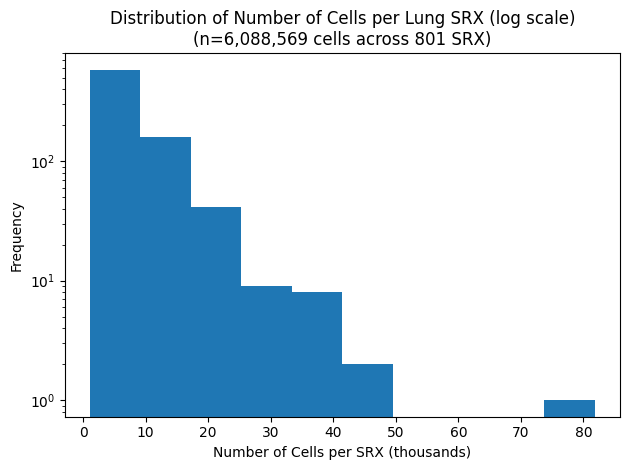

In [77]:
# distribution of number of cells in the dataset
plt.hist(lung_intersection["obs_count"] / 1000, log=True)
plt.title(f"Distribution of Number of Cells per Lung SRX (log scale)\n(n={np.sum(lung_intersection['obs_count']):,} cells across {len(lung_intersection):,} SRX)")
plt.xlabel("Number of Cells per SRX (thousands)")
plt.ylabel("Frequency")
plt.tight_layout()
fig = plt.gcf()
fig.savefig(IMAGES_DIR / "lung_cell_number_hist.svg", bbox_inches="tight")

# 5. Save CSV with select datasets

Save a CSV with the datasets selected for downstream analysis titled `datasets.csv`. Also save a CSV with key information of the 3 representative datasets I will use for exploratory analysis titled `quantiles_datasets.csv`.

In [78]:
# Full dataset
datasets_df = lung_intersection[["srx_accession", "file_path", "obs_count"]]
datasets_df.to_csv(_repo_root() / "metadata_analysis/v2_lung/datasets.csv", index=False)

# Quantiles
split = [0.25, 0.5, 0.75]
q = datasets_df["obs_count"].quantile(split)
quantiles_df = datasets_df[datasets_df["obs_count"].isin(q)][["srx_accession", "file_path", "obs_count"]].sort_values(by="obs_count")
quantiles_df["quantile"] = split
quantiles_df.to_csv(_repo_root() / "metadata_analysis/v2_lung/quantiles_datasets.csv", index=False)

# 6. Helper functions
## SRX lookup

In [79]:
def obs_rows_for_srx(
    srx_accession: str,
    *,
    parquet_path: Path | None = None,
    columns: list[str] | None = None,
) -> pd.DataFrame:
    """One SRX from obs_metadata: filter pushed into the parquet scan (no full-file load)."""
    dset = ds.dataset(str(parquet_path or OBS_PARQUET), format="parquet")
    tbl = dset.to_table(
        columns=columns,
        filter=ds.field("SRX_accession") == srx_accession,
    )
    return tbl.to_pandas()

In [80]:
# Peek into the SRX with the most cells
biggest_count = np.max(lung_intersection["obs_count"])
biggest_srx = lung_intersection[lung_intersection["obs_count"] == biggest_count]["srx_accession"].values[0]
obs_rows_for_srx(biggest_srx)

,cell_barcode,SRX_accession,gene_count_Unique,umi_count_Unique,gene_count_UniqueAndMult-EM,umi_count_UniqueAndMult-EM,gene_count_UniqueAndMult-Uniform,umi_count_UniqueAndMult-Uniform,cell_type,cell_ontology_term_id
0,AAACCCAAGAAACACT,SRX19352021,519,655.0,599,732.000122,607,732.000244,,
1,AAACCCAAGAACTGAT,SRX19352021,564,702.0,612,768.000000,615,767.999939,,
2,AAACCCAAGAAGGATG,SRX19352021,428,513.0,476,561.000000,481,561.000000,,
3,AAACCCAAGAATCCCT,SRX19352021,396,477.0,434,523.000000,436,523.000000,,
4,AAACCCAAGAATGTTG,SRX19352021,437,545.0,475,598.000061,478,598.000122,,
...,...,...,...,...,...,...,...,...,...,...
81806,TTTGTTGTCTCCTGCA,SRX19352021,498,623.0,535,695.999878,541,696.000000,,
81807,TTTGTTGTCTCTAAGG,SRX19352021,495,613.0,554,672.000061,557,672.000122,,
81808,TTTGTTGTCTGGAGAG,SRX19352021,397,473.0,434,517.000061,437,517.000122,,
81809,TTTGTTGTCTTAGCAG,SRX19352021,324,389.0,368,427.000000,369,427.000031,,
